## Xử lý miền tần số ngắn hạn cho tiếng nói (phiên bản Python)

Notebook này tái hiện cấu trúc và các hình trong tài liệu *"Short-Term Frequency Domain Processing of Speech"* (Virtual Lab – IIT Guwahati) nhưng viết bằng Python thay vì MATLAB.

Tập tin tiếng nói chính có tên `toiyeu.wav` và nằm cùng thư mục với notebook. Hãy đặt file vào đây trước khi chạy các cell.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True


def load_speech_wav(filename="toiyeu.wav"):
    """Nạp tín hiệu tiếng nói và chuẩn hóa về khoảng [-1, 1]."""
    fs, x = wavfile.read(filename)
    if x.dtype.kind in ["i", "u"]:
        max_val = np.iinfo(x.dtype).max
        x = x.astype(np.float64) / max_val
    else:
        x = x.astype(np.float64)
    if x.ndim > 1:
        x = x[:, 0]
    return fs, x


def compute_spectrum(x, fs):
    """Tính FFT một phía cùng trục tần số, biên độ tuyến tính và log (dB)."""
    N = len(x)
    N_fft = int(2 ** np.ceil(np.log2(max(N, 1))))
    X = np.fft.rfft(x * np.hanning(N), n=N_fft)
    freqs = np.fft.rfftfreq(N_fft, d=1.0 / fs)
    mag = np.abs(X)
    mag_db = 10 * np.log10(np.maximum(mag**2, 1e-12))
    return freqs, mag, mag_db


def extract_segment(x, fs, start_time_s, duration_s):
    """Cắt đoạn tín hiệu (giây) và đệm 0 nếu vượt quá độ dài tín hiệu."""
    start_idx = int(round(start_time_s * fs))
    length = int(round(duration_s * fs))
    end_idx = start_idx + length
    seg = np.zeros(length, dtype=float)
    if start_idx < len(x):
        valid_end = min(end_idx, len(x))
        seg[: valid_end - start_idx] = x[start_idx:valid_end]
    t = np.arange(length) / fs
    return t, seg


def frame_signal(x, fs, frame_dur_s, frame_shift_s):
    """Chia khung với cửa sổ Hanning.

    Trả về: ma trận khung (số khung × độ dài khung) và trục thời gian tâm khung (giây).
    """
    frame_len = int(round(frame_dur_s * fs))
    frame_shift = int(round(frame_shift_s * fs))
    if frame_len <= 0:
        raise ValueError("Độ dài khung phải dương")

    num_frames = 1 + max(0, (len(x) - frame_len) // frame_shift)
    if num_frames <= 0:
        return np.zeros((0, frame_len)), np.array([])

    frames = np.zeros((num_frames, frame_len), dtype=float)
    win = signal.windows.hann(frame_len, sym=False)

    for i in range(num_frames):
        start = i * frame_shift
        frames[i] = x[start:start + frame_len] * win

    frame_centers = (np.arange(num_frames) * frame_shift + frame_len / 2) / fs
    return frames, frame_centers


def stft_log_spectrogram(x, fs, frame_dur_s=0.02, frame_shift_s=0.01):
    """Tính phổ log của STFT bằng cách chia khung thủ công rồi FFT."""
    frames, t_frames = frame_signal(x, fs, frame_dur_s, frame_shift_s)
    if frames.size == 0:
        return np.array([]), np.array([]), np.array([[]])

    frame_len = frames.shape[1]
    N_fft = int(2 ** np.ceil(np.log2(frame_len)))
    spec = np.fft.rfft(frames, n=N_fft, axis=1)
    mag = np.abs(spec)
    mag_db = 10 * np.log10(np.maximum(mag**2, 1e-12))
    freqs = np.fft.rfftfreq(N_fft, d=1.0 / fs)

    return freqs, t_frames, mag_db


print("Đã sẵn sàng import và các hàm hỗ trợ. Đặt 'toiyeu.wav' cùng thư mục trước khi chạy.")


Đã sẵn sàng import và các hàm hỗ trợ. Đặt 'toiyeu.wav' cùng thư mục trước khi chạy.


## Phần 1 – Phân tích toàn tín hiệu (Hình 1)

Phần này nạp file `toiyeu.wav`, vẽ toàn bộ dạng sóng và hiển thị phổ biên độ tuyến tính cũng như phổ log.


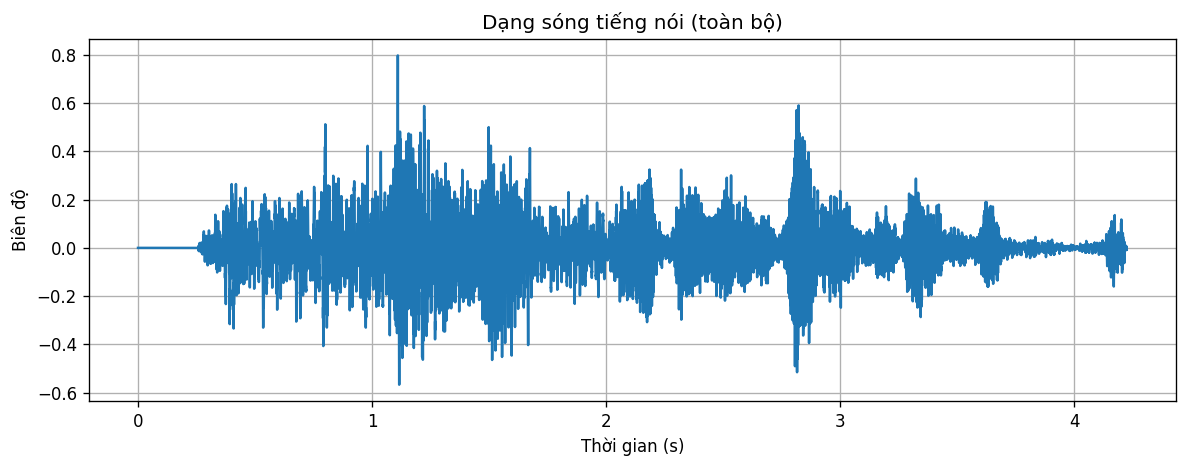

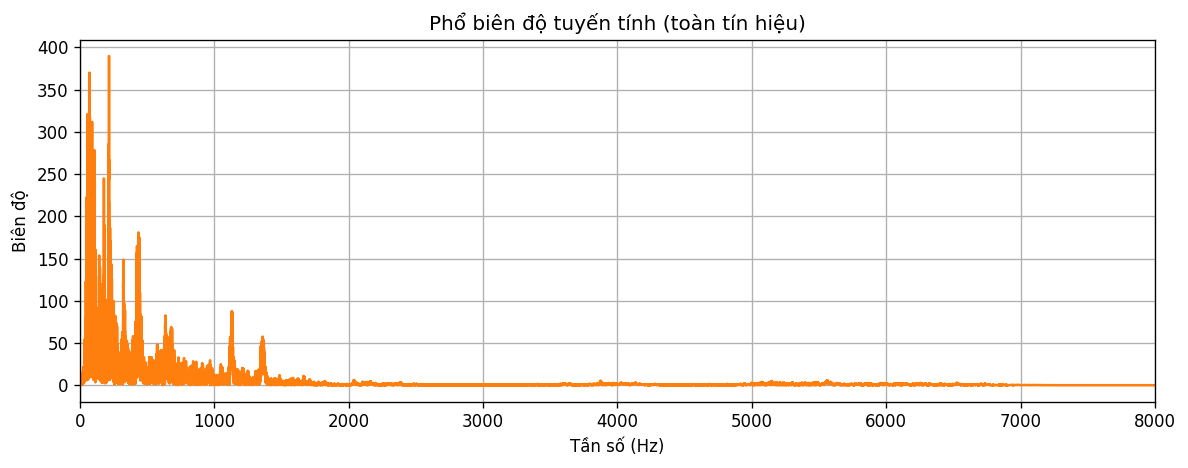

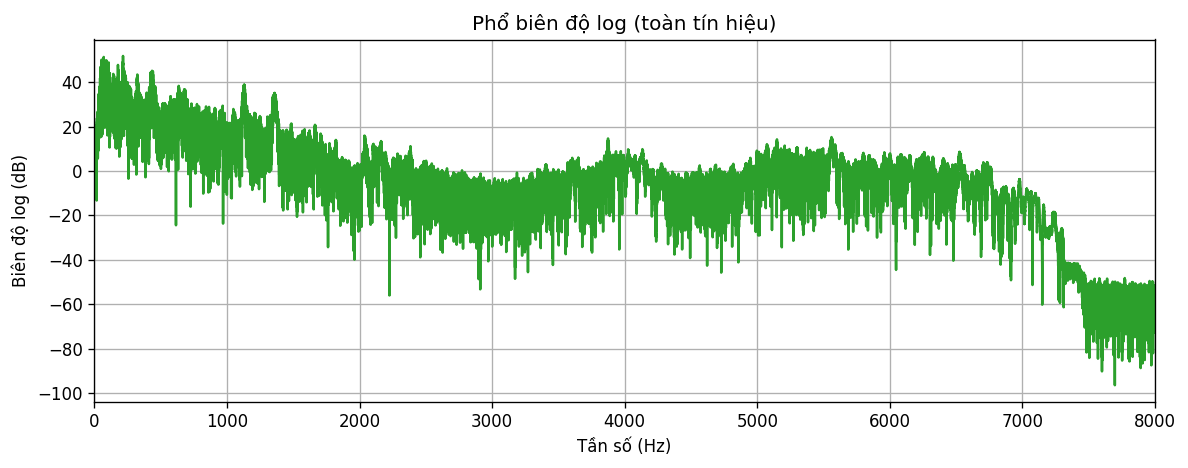

Hoàn tất Phần 1. Tần số lấy mẫu: 16000 Hz, thời lượng: 4.224 s


In [20]:
# --- PHẦN 1: Phân tích toàn tín hiệu (Hình 1) ---

fs, x = load_speech_wav("toiyeu.wav")
T = len(x) / fs

t = np.linspace(0, T, len(x), endpoint=False)

plt.figure(figsize=(10, 4))
plt.plot(t, x, color='C0')
plt.xlabel('Thời gian (s)')
plt.ylabel('Biên độ')
plt.title('Dạng sóng tiếng nói (toàn bộ)')
plt.tight_layout()
plt.show()

freqs, mag, mag_db = compute_spectrum(x, fs)

plt.figure(figsize=(10, 4))
plt.plot(freqs, mag, color='C1')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ')
plt.title('Phổ biên độ tuyến tính (toàn tín hiệu)')
plt.xlim([0, fs / 2])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(freqs, mag_db, color='C2')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ log (dB)')
plt.title('Phổ biên độ log (toàn tín hiệu)')
plt.xlim([0, fs / 2])
plt.tight_layout()
plt.show()

print(f'Hoàn tất Phần 1. Tần số lấy mẫu: {fs} Hz, thời lượng: {T:.3f} s')


## Phần 2 – Hữu thanh / vô thanh / khoảng lặng (Hình 2)

Phần này cắt ba đoạn dài 30 ms tương ứng (xấp xỉ) với vùng hữu thanh, vô thanh và khoảng lặng, rồi với mỗi đoạn ta vẽ:

- dạng sóng
- phổ biên độ tuyến tính
- phổ biên độ log

Các đồ thị được sắp thành lưới 3 × 3 giống Hình 2 trong PDF tham chiếu.

Nếu cần, bạn có thể chỉnh thời điểm bắt đầu của ba vùng ngay trong ô mã.


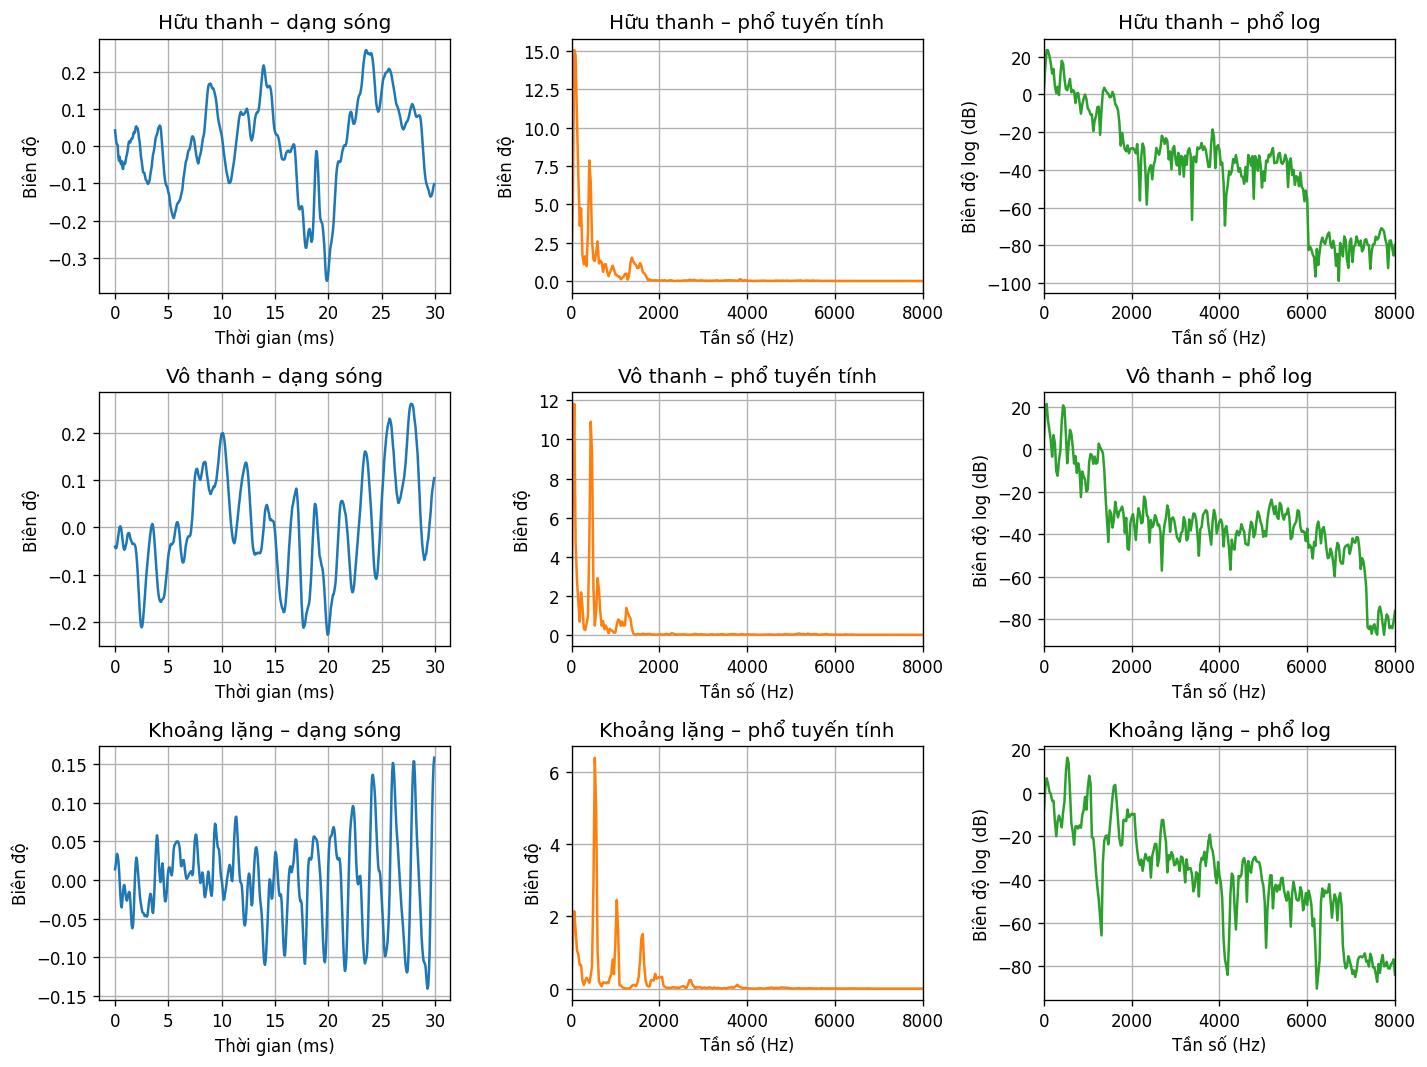

Hoàn tất Phần 2. Đã vẽ lưới 3×3 cho các đoạn hữu thanh / vô thanh / khoảng lặng.


In [21]:
# --- PHẦN 2: Hữu thanh / vô thanh / khoảng lặng (Hình 2) ---

segment_dur_s = 0.030  # 30 ms

# Chọn thời điểm bắt đầu theo kinh nghiệm (có thể chỉnh tay)
# - hữu thanh: khoảng 25% độ dài tín hiệu
# - vô thanh: khoảng 50%
# - khoảng lặng: khoảng 85%
T = len(x) / fs
voiced_start_s = 0.25 * T
unvoiced_start_s = 0.50 * T
silence_start_s = 0.85 * T

segments_info = [
    ("Hữu thanh", voiced_start_s),
    ("Vô thanh", unvoiced_start_s),
    ("Khoảng lặng", silence_start_s),
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))

for row, (label, start_s) in enumerate(segments_info):
    t_seg, x_seg = extract_segment(x, fs, start_s, segment_dur_s)
    freqs_seg, mag_seg, mag_db_seg = compute_spectrum(x_seg, fs)

    ax_time = axes[row, 0]
    ax_time.plot(t_seg * 1000, x_seg, color='C0')
    ax_time.set_xlabel('Thời gian (ms)')
    ax_time.set_ylabel('Biên độ')
    ax_time.set_title(f'{label} – dạng sóng')

    ax_lin = axes[row, 1]
    ax_lin.plot(freqs_seg, mag_seg, color='C1')
    ax_lin.set_xlim([0, fs / 2])
    ax_lin.set_xlabel('Tần số (Hz)')
    ax_lin.set_ylabel('Biên độ')
    ax_lin.set_title(f'{label} – phổ tuyến tính')

    ax_log = axes[row, 2]
    ax_log.plot(freqs_seg, mag_db_seg, color='C2')
    ax_log.set_xlim([0, fs / 2])
    ax_log.set_xlabel('Tần số (Hz)')
    ax_log.set_ylabel('Biên độ log (dB)')
    ax_log.set_title(f'{label} – phổ log')

plt.tight_layout()
plt.show()

print('Hoàn tất Phần 2. Đã vẽ lưới 3×3 cho các đoạn hữu thanh / vô thanh / khoảng lặng.')


## Phần 3 – Biến đổi Fourier ngắn hạn (STFT) (Hình 3)

Phần này tính STFT với các tham số:

- độ dài khung: 20 ms
- bước trượt: 10 ms
- cửa sổ: Hanning

Sau đó vẽ phổ log dạng spectrogram (giống hình 3D trong tài liệu).


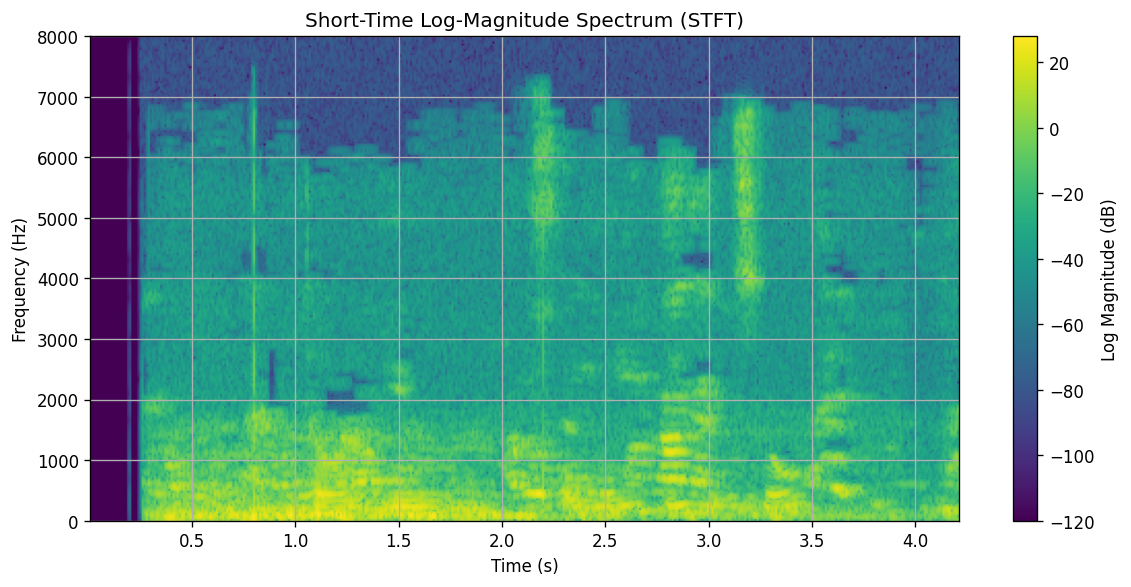

Section 3 complete. STFT log-magnitude spectrogram plotted.


In [ ]:
# --- PHẦN 3: STFT (Hình 3) ---

frame_dur_s = 0.020  # 20 ms
frame_shift_s = 0.010  # 10 ms

freqs_stft, t_stft, mag_db_stft = stft_log_spectrogram(x, fs, frame_dur_s, frame_shift_s)

if mag_db_stft.size == 0:
    print("Tín hiệu quá ngắn để tính STFT với tham số hiện tại.")
else:
    plt.figure(figsize=(10, 5))
    extent = [t_stft[0], t_stft[-1], freqs_stft[0], freqs_stft[-1]]
    plt.imshow(
        mag_db_stft.T,
        origin='lower',
        aspect='auto',
        extent=extent,
        cmap='viridis'
    )
    plt.colorbar(label='Biên độ log (dB)')
    plt.xlabel('Thời gian (s)')
    plt.ylabel('Tần số (Hz)')
    plt.title('Phổ STFT (biên độ log)')
    plt.tight_layout()
    plt.show()

print('Hoàn tất Phần 3. Đã vẽ spectrogram STFT.')


## Phần 4 – Phổ thực so với phổ chập (Hình 4)

Phần này tạo sóng sin tổng hợp 200 Hz và so sánh phổ của nó trong hai độ dài:

- 30 ms
- 250 ms

Mỗi độ dài gồm:

1. dạng sóng thời gian
2. phổ biên độ tuyến tính
3. phổ biên độ log

(Tổng cộng 6 biểu đồ, giống Hình 4).


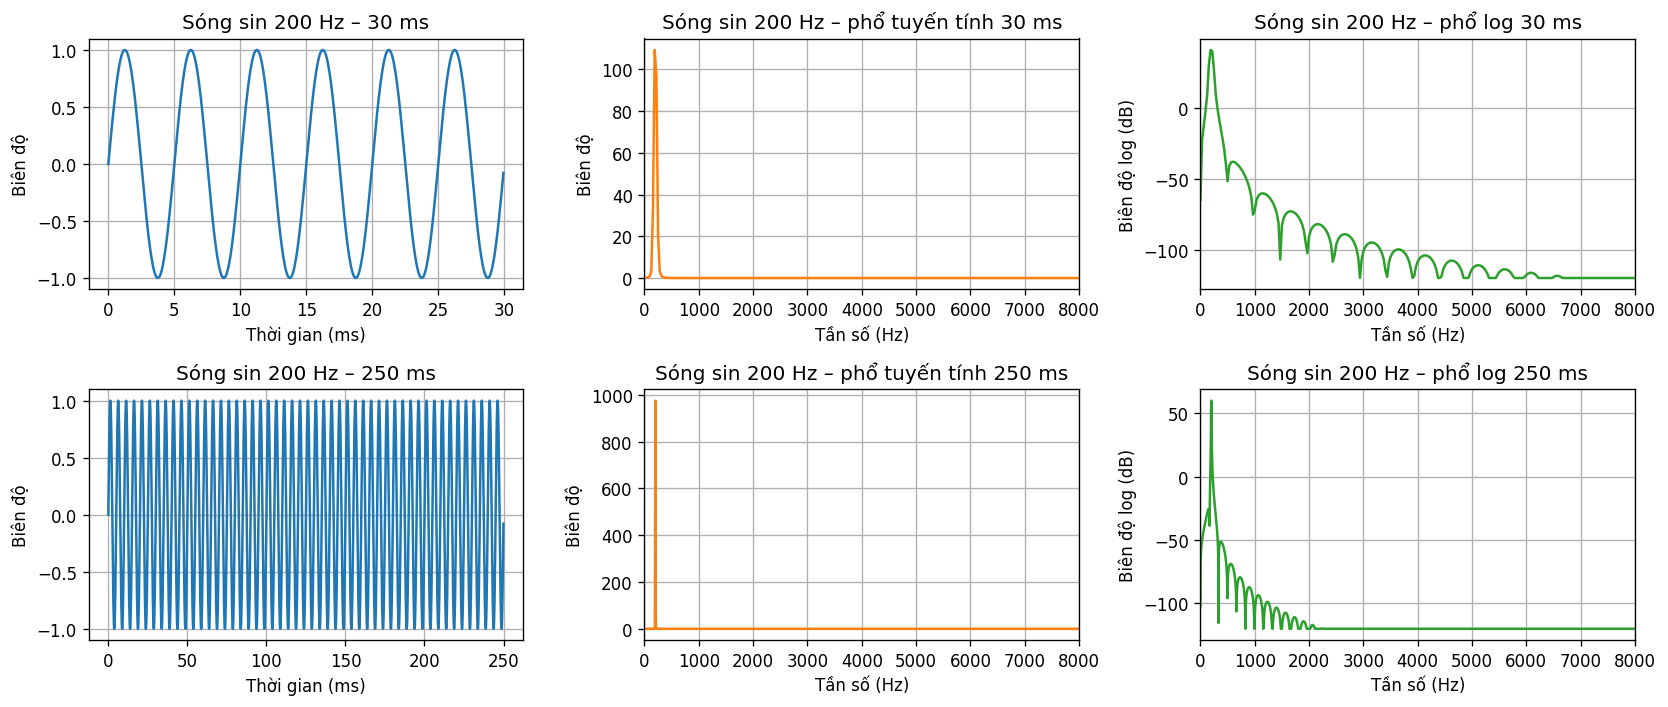

Hoàn tất Phần 4. Đã vẽ 6 biểu đồ cho sóng sin 200 Hz.


In [16]:
# --- PHẦN 4: Phổ thực vs phổ chập (Hình 4) ---

f0 = 200.0  # Hz

short_dur = 0.030  # 30 ms
long_dur = 0.250   # 250 ms

fs_sine = fs


def generate_sine_and_spectrum(f0, fs, duration_s):
    N = int(round(duration_s * fs))
    t = np.arange(N) / fs
    x_sine = np.sin(2 * np.pi * f0 * t)
    freqs_sine, mag_sine, mag_db_sine = compute_spectrum(x_sine, fs)
    return t, x_sine, freqs_sine, mag_sine, mag_db_sine

(t_short, x_short,
 freqs_short, mag_short, mag_db_short) = generate_sine_and_spectrum(f0, fs_sine, short_dur)

(t_long, x_long,
 freqs_long, mag_long, mag_db_long) = generate_sine_and_spectrum(f0, fs_sine, long_dur)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

axes[0, 0].plot(t_short * 1000, x_short, color='C0')
axes[0, 0].set_xlabel('Thời gian (ms)')
axes[0, 0].set_ylabel('Biên độ')
axes[0, 0].set_title('Sóng sin 200 Hz – 30 ms')

axes[0, 1].plot(freqs_short, mag_short, color='C1')
axes[0, 1].set_xlim([0, fs_sine / 2])
axes[0, 1].set_xlabel('Tần số (Hz)')
axes[0, 1].set_ylabel('Biên độ')
axes[0, 1].set_title('Sóng sin 200 Hz – phổ tuyến tính 30 ms')

axes[0, 2].plot(freqs_short, mag_db_short, color='C2')
axes[0, 2].set_xlim([0, fs_sine / 2])
axes[0, 2].set_xlabel('Tần số (Hz)')
axes[0, 2].set_ylabel('Biên độ log (dB)')
axes[0, 2].set_title('Sóng sin 200 Hz – phổ log 30 ms')

axes[1, 0].plot(t_long * 1000, x_long, color='C0')
axes[1, 0].set_xlabel('Thời gian (ms)')
axes[1, 0].set_ylabel('Biên độ')
axes[1, 0].set_title('Sóng sin 200 Hz – 250 ms')

axes[1, 1].plot(freqs_long, mag_long, color='C1')
axes[1, 1].set_xlim([0, fs_sine / 2])
axes[1, 1].set_xlabel('Tần số (Hz)')
axes[1, 1].set_ylabel('Biên độ')
axes[1, 1].set_title('Sóng sin 200 Hz – phổ tuyến tính 250 ms')

axes[1, 2].plot(freqs_long, mag_db_long, color='C2')
axes[1, 2].set_xlim([0, fs_sine / 2])
axes[1, 2].set_xlabel('Tần số (Hz)')
axes[1, 2].set_ylabel('Biên độ log (dB)')
axes[1, 2].set_title('Sóng sin 200 Hz – phổ log 250 ms')

plt.tight_layout()
plt.show()

print('Hoàn tất Phần 4. Đã vẽ 6 biểu đồ cho sóng sin 200 Hz.')


## Phần 5 – So sánh hàm cửa sổ (Hình 5 & 6)

Với một đoạn hữu thanh 30 ms, phần này áp dụng ba cửa sổ khác nhau:

- chữ nhật
- Hamming
- Hanning

Mỗi cửa sổ bao gồm:

1. tín hiệu sau khi nhân cửa sổ trong miền thời gian
2. phổ biên độ tuyến tính
3. phổ biên độ log

(Tổng cộng 9 biểu đồ, tương ứng Hình 5 và 6).


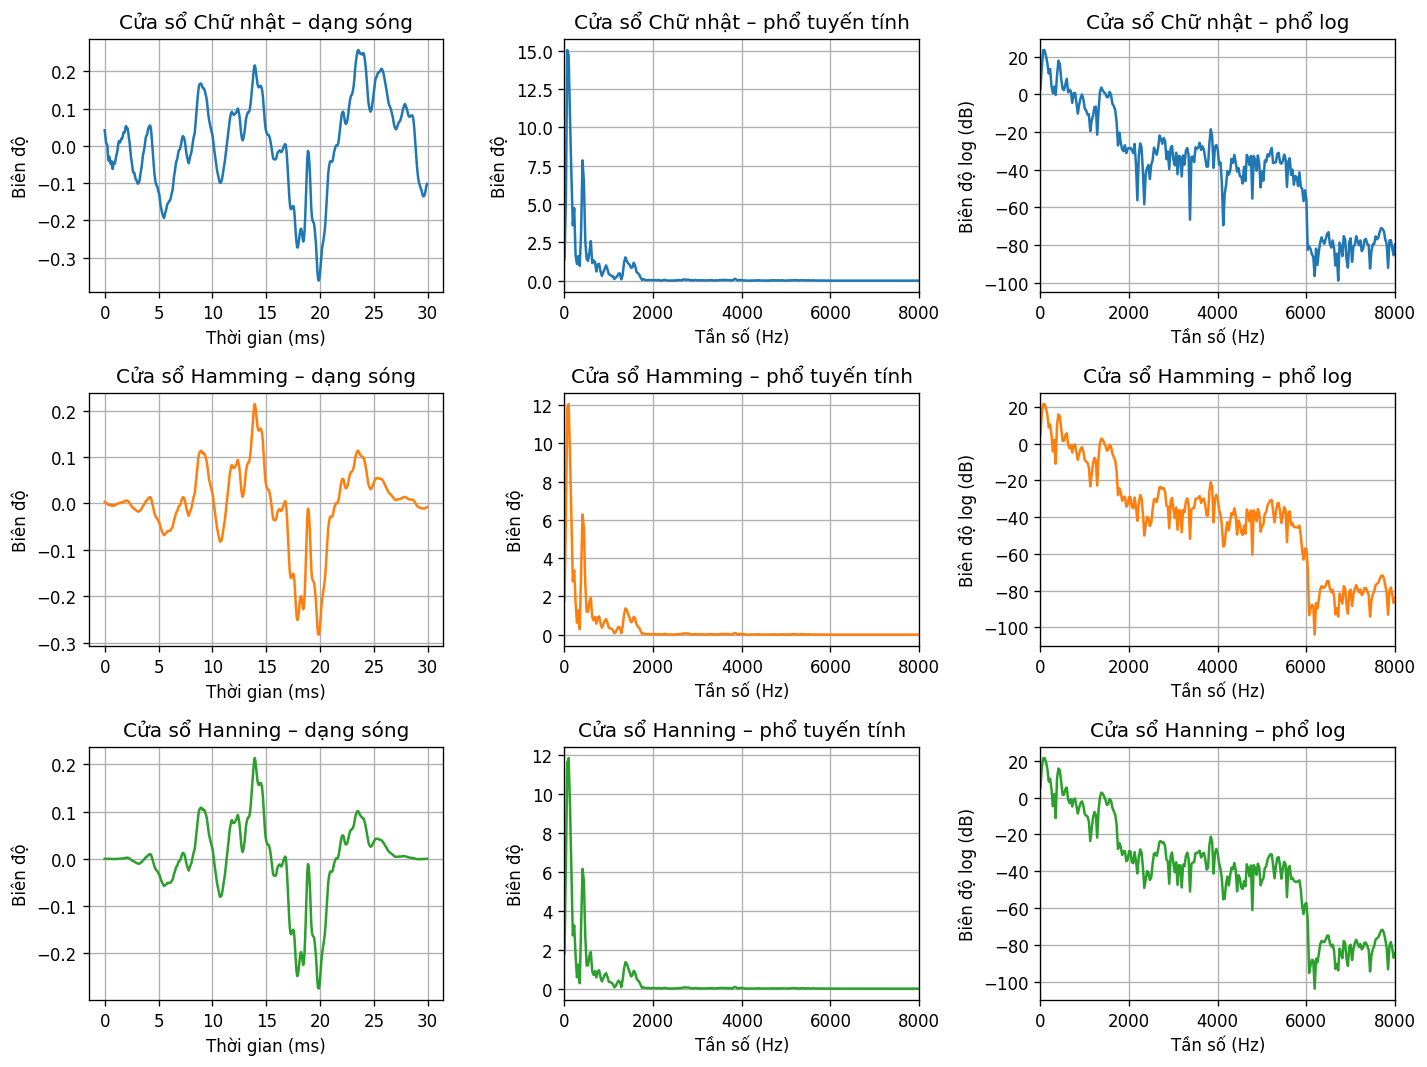

Hoàn tất Phần 5. Đã so sánh cửa sổ chữ nhật, Hamming và Hanning.


In [17]:
# --- PHẦN 5: So sánh hàm cửa sổ (Hình 5 & 6) ---

voiced_win_dur_s = 0.030  # 30 ms

voiced_start_s = 0.25 * T

_, voiced_seg = extract_segment(x, fs, voiced_start_s, voiced_win_dur_s)
N_voiced = len(voiced_seg)
t_voiced = np.arange(N_voiced) / fs * 1000  # ms

rect_win = np.ones(N_voiced)
hamming_win = signal.windows.hamming(N_voiced, sym=False)
hanning_win = signal.windows.hann(N_voiced, sym=False)

windows = [
    ("Chữ nhật", rect_win, 'C0'),
    ("Hamming", hamming_win, 'C1'),
    ("Hanning", hanning_win, 'C2'),
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))

for row, (label, win, color) in enumerate(windows):
    xw = voiced_seg * win
    freqs_w, mag_w, mag_db_w = compute_spectrum(xw, fs)

    ax_time = axes[row, 0]
    ax_time.plot(t_voiced, xw, color=color)
    ax_time.set_xlabel('Thời gian (ms)')
    ax_time.set_ylabel('Biên độ')
    ax_time.set_title(f'Cửa sổ {label} – dạng sóng')

    ax_lin = axes[row, 1]
    ax_lin.plot(freqs_w, mag_w, color=color)
    ax_lin.set_xlim([0, fs / 2])
    ax_lin.set_xlabel('Tần số (Hz)')
    ax_lin.set_ylabel('Biên độ')
    ax_lin.set_title(f'Cửa sổ {label} – phổ tuyến tính')

    ax_log = axes[row, 2]
    ax_log.plot(freqs_w, mag_db_w, color=color)
    ax_log.set_xlim([0, fs / 2])
    ax_log.set_xlabel('Tần số (Hz)')
    ax_log.set_ylabel('Biên độ log (dB)')
    ax_log.set_title(f'Cửa sổ {label} – phổ log')

plt.tight_layout()
plt.show()

print('Hoàn tất Phần 5. Đã so sánh cửa sổ chữ nhật, Hamming và Hanning.')


## Phần 6 – Ảnh hưởng của độ dài cửa sổ (Hình 8)

Với một đoạn tiếng nói 300 ms, phần này so sánh ảnh hưởng của các độ dài cửa sổ lên phổ log:

- đoạn 3 ms (đệm 0 cho đủ 300 ms)
- đoạn 30 ms (đệm 0 cho đủ 300 ms)
- đoạn 300 ms (không đệm)

Mỗi trường hợp bao gồm:

1. dạng sóng trong miền thời gian (trên khung 300 ms)
2. phổ log tương ứng

(Tổng cộng 6 biểu đồ, giống bố cục Hình 8).


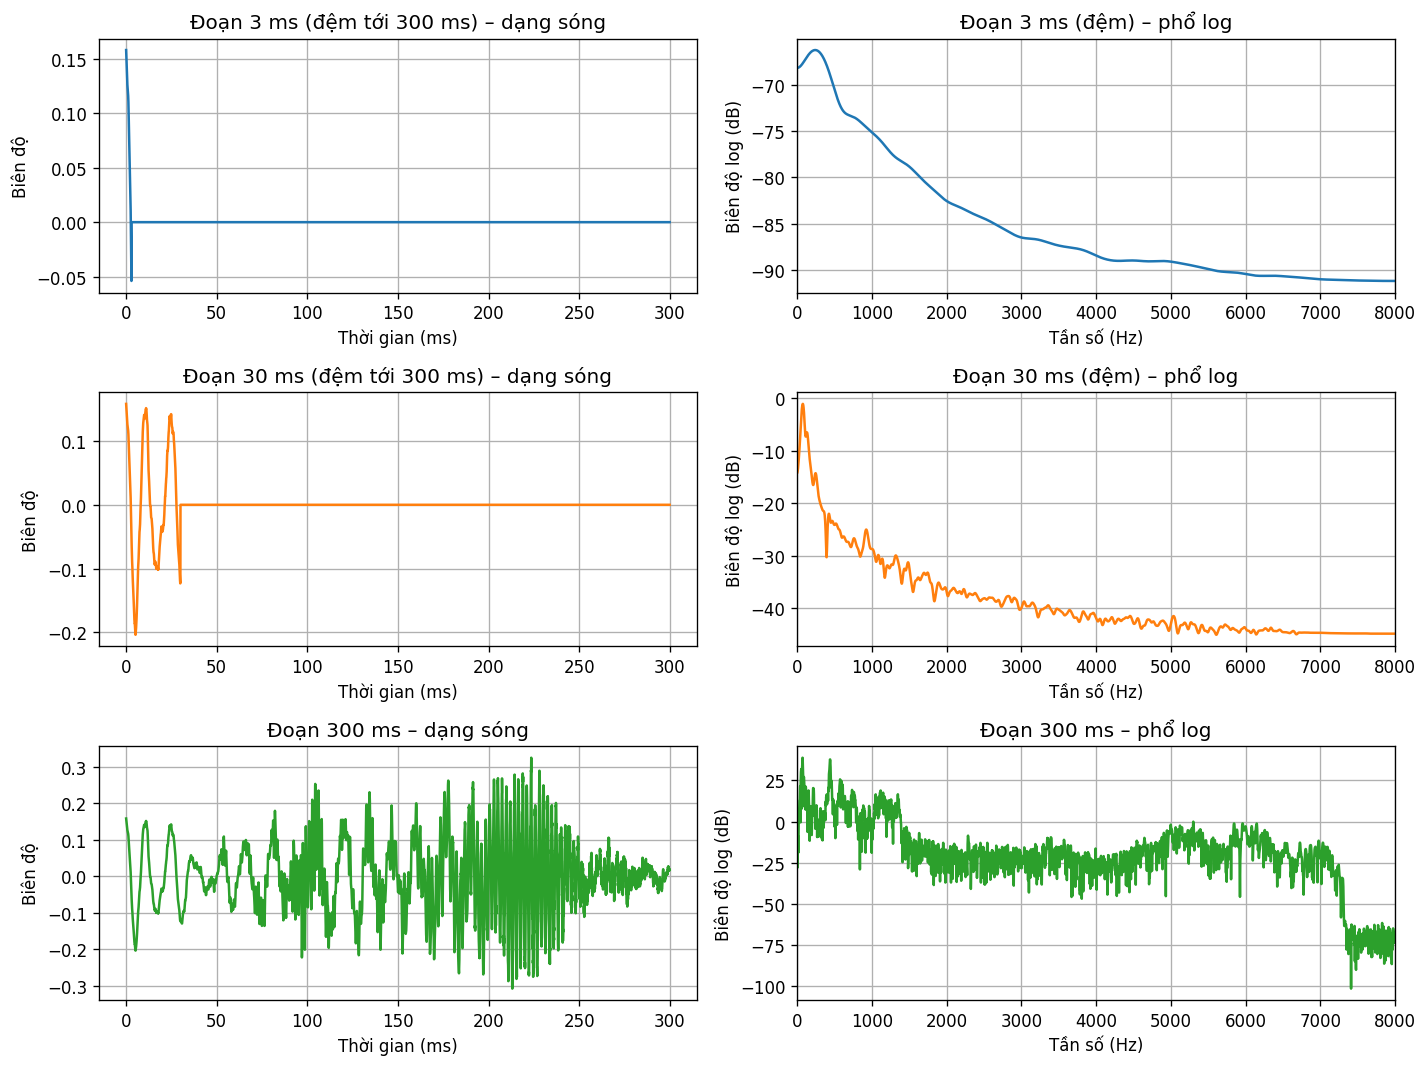

Hoàn tất Phần 6. Đã minh họa ảnh hưởng của độ dài cửa sổ (3, 30, 300 ms).


In [18]:
# --- PHẦN 6: Ảnh hưởng độ dài cửa sổ (Hình 8) ---

analysis_dur_s = 0.300  # 300 ms

T = len(x) / fs
start_center_s = max(0.0, 0.5 * T - analysis_dur_s / 2)


def extract_and_pad(x, fs, start_time_s, seg_dur_s, target_dur_s):
    target_len = int(round(target_dur_s * fs))
    _, seg = extract_segment(x, fs, start_time_s, seg_dur_s)
    out = np.zeros(target_len, dtype=float)
    L = min(target_len, len(seg))
    out[:L] = seg[:L]
    t = np.arange(target_len) / fs * 1000  # ms
    return t, out


t_3ms, x_3ms = extract_and_pad(x, fs, start_center_s, 0.003, analysis_dur_s)
t_30ms, x_30ms = extract_and_pad(x, fs, start_center_s, 0.030, analysis_dur_s)
t_300ms, x_300ms = extract_and_pad(x, fs, start_center_s, 0.300, analysis_dur_s)

freqs_3, _, mag_db_3 = compute_spectrum(x_3ms, fs)
freqs_30, _, mag_db_30 = compute_spectrum(x_30ms, fs)
freqs_300, _, mag_db_300 = compute_spectrum(x_300ms, fs)

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

axes[0, 0].plot(t_3ms, x_3ms, color='C0')
axes[0, 0].set_xlabel('Thời gian (ms)')
axes[0, 0].set_ylabel('Biên độ')
axes[0, 0].set_title('Đoạn 3 ms (đệm tới 300 ms) – dạng sóng')

axes[0, 1].plot(freqs_3, mag_db_3, color='C0')
axes[0, 1].set_xlim([0, fs / 2])
axes[0, 1].set_xlabel('Tần số (Hz)')
axes[0, 1].set_ylabel('Biên độ log (dB)')
axes[0, 1].set_title('Đoạn 3 ms (đệm) – phổ log')

axes[1, 0].plot(t_30ms, x_30ms, color='C1')
axes[1, 0].set_xlabel('Thời gian (ms)')
axes[1, 0].set_ylabel('Biên độ')
axes[1, 0].set_title('Đoạn 30 ms (đệm tới 300 ms) – dạng sóng')

axes[1, 1].plot(freqs_30, mag_db_30, color='C1')
axes[1, 1].set_xlim([0, fs / 2])
axes[1, 1].set_xlabel('Tần số (Hz)')
axes[1, 1].set_ylabel('Biên độ log (dB)')
axes[1, 1].set_title('Đoạn 30 ms (đệm) – phổ log')

axes[2, 0].plot(t_300ms, x_300ms, color='C2')
axes[2, 0].set_xlabel('Thời gian (ms)')
axes[2, 0].set_ylabel('Biên độ')
axes[2, 0].set_title('Đoạn 300 ms – dạng sóng')

axes[2, 1].plot(freqs_300, mag_db_300, color='C2')
axes[2, 1].set_xlim([0, fs / 2])
axes[2, 1].set_xlabel('Tần số (Hz)')
axes[2, 1].set_ylabel('Biên độ log (dB)')
axes[2, 1].set_title('Đoạn 300 ms – phổ log')

plt.tight_layout()
plt.show()

print('Hoàn tất Phần 6. Đã minh họa ảnh hưởng của độ dài cửa sổ (3, 30, 300 ms).')
